# **Data Preprocessing and Automated Labeling Pipeline**

Notebook này thiết lập nền tảng dữ liệu cho hệ thống phân tích cảm xúc đa phương thức. Trọng tâm của tài liệu bao gồm việc kiểm định chất lượng dữ liệu thô, làm sạch, chuẩn hóa văn bản tiếng Việt và đánh giá tác động của các kỹ thuật tiền xử lý trước khi tiến hành trích xuất đặc trưng.

---

## **1. Environment Setup**

Phân hệ này khởi tạo môi trường làm việc, nạp các thư viện toán học và xử lý dữ liệu lõi nhằm đảm bảo tính nhất quán và khả năng tái lập của toàn bộ quy trình.

### 1.1. Import Libraries

Khai báo và khởi tạo toàn bộ các thư viện cần thiết cho luồng tiền xử lý. Việc tập trung không gian nạp thư viện ngay từ đầu giúp quản lý không gian tên hiệu quả, tránh xung đột và cung cấp cái nhìn tổng quan về các công cụ toán học, thống kê, học máy và kiến trúc mạng nơ ron được sử dụng trong suốt tài liệu.

In [1]:
# 1. Standard Library Imports
# Used for cryptographic hashing, file paths, I/O operations, and timestamping.
import hashlib
import io
import json
import os
import sys
from datetime import datetime

from dotenv import load_dotenv
load_dotenv() 
# Append project root to system path to enable absolute imports from the 'ai_engine' core.
sys.path.append(os.path.abspath(".."))

# 2. Core Scientific and Data Manipulation Libraries
# Used for matrix operations, large-scale data manipulation, and execution tracking.
import numpy as np
import pandas as pd
from tqdm import tqdm

# 3. Data Visualization Libraries
# Used for plotting statistical distributions, metrics, and quantitative analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Natural Language Processing & Parallel Computing
# Used for distributed text cleaning, morphological analysis, and subword tokenization.
from pandarallel import pandarallel
import underthesea
from transformers import AutoTokenizer

# 5. Machine Learning and Feature Engineering (scikit-learn)
# Used for sparse vectorization, mutual information scoring, and baseline modeling.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB

# 6. Proprietary Project Modules
# Custom high-performance pipelines for text normalization and zero-shot semantic analysis.
from ai_engine.text_processing.preprocessor import TextCleaner
from ai_engine.text_processing.sentiment_analysis import NextGenReviewAnalyzer

### 1.2. Load Dataset

Nạp tập dữ liệu đánh giá sản phẩm thô vào bộ nhớ. Đây là nguồn dữ liệu chuẩn để thực hiện mọi bước kiểm định và tiền xử lý tiếp theo.

In [2]:
DATA_PATH = "../data/raw/all_reviews.csv"
df = pd.read_csv(DATA_PATH)

display(df.head())

,product_name,text,rating,date,image_urls,product_url,scraped_at
0,Sách Thầm Yêu Ánh Dương Rực Rỡ,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,2026-04-24,https://salt.tikicdn.com/ts/review/b0/35/30/e5...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380507
1,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,2026-04-21,https://salt.tikicdn.com/ts/review/3b/db/ac/ee...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380617
2,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-18,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380634
3,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-03,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380658
4,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,2026-03-12,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380672


## **2. Data Quality Assurance and Initial EDA**

Quy trình kiểm định chất lượng dữ liệu giúp nhận diện các bất thường phát sinh từ thao tác thu thập. Việc làm sạch sớm giúp ngăn chặn nhiễu lan truyền sang các mô hình học máy ở giai đoạn sau.

### 2.1. Basic Descriptive Statistics

Khảo sát quy mô tập dữ liệu, cấu trúc cột và thống kê mô tả cơ bản để đánh giá mức độ khuyết thiếu thông tin. Phân tích này là cơ sở để ra quyết định điền khuyết hoặc loại bỏ mẫu.

In [3]:
num_rows, num_cols = df.shape
print(f"Number of records: {num_rows:,}")
print(f"Number of features: {num_cols}")

Number of records: 9,386
Number of features: 7


In [4]:
# Display schema: data types & non-null counts
print("Dataset schema overview:")
df.info()

Dataset schema overview:
<class 'pandas.DataFrame'>
RangeIndex: 9386 entries, 0 to 9385
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_name  9386 non-null   str  
 1   text          6193 non-null   str  
 2   rating        9386 non-null   int64
 3   date          9338 non-null   str  
 4   image_urls    3916 non-null   str  
 5   product_url   9386 non-null   str  
 6   scraped_at    9386 non-null   str  
dtypes: int64(1), str(6)
memory usage: 513.4 KB


In [5]:
# Target Variable Analysis
print("Descriptive statistics for 'rating':")
print(df["rating"].describe())

Descriptive statistics for 'rating':
count    9386.000000
mean        4.848604
std         0.580253
min         1.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64


In [6]:
# Missing Value Analysis
missing_rate = df.isnull().mean().mul(100).sort_values(ascending=False)
print("Missing value percentage by column (%):")
print(missing_rate)

Missing value percentage by column (%):
image_urls      58.278287
text            34.018751
date             0.511400
rating           0.000000
product_name     0.000000
product_url      0.000000
scraped_at       0.000000
dtype: float64


**Nhận xét:** Các trường dữ liệu văn bản và liên kết hình ảnh như `image_urls` hoặc `text` thường có tỷ lệ thiếu cao do review không kèm ảnh hoặc rỗng nội dung. Đây là đặc thù của dữ liệu thương mại điện tử khi người dùng chỉ để lại điểm số mà không đính kèm nội dung chi tiết. Các bản ghi này cần được xử lý trước khi đưa vào mô hình ngôn ngữ.

### 2.2. Anomaly Detection and Handling

Quá trình cào dữ liệu thường sinh ra các bản ghi trùng lặp cơ học hoặc thu thập phải các bình luận không mang giá trị thông tin ngữ nghĩa.

#### 2.2.1. Handling Duplicates

Thuật toán băm MD5 được áp dụng lên nội dung đánh giá để ánh xạ các chuỗi văn bản dài thành các mã định danh duy nhất. Phương pháp này tối ưu hóa tốc độ tìm kiếm và loại bỏ các bản sao chính xác tuyệt đối giữa các nền tảng khác nhau.

In [7]:
initial_record_count = len(df)

# Generate MD5 hash for text content to identify duplicates
df["text_hash"] = df["text"].apply(
    lambda x: hashlib.md5(str(x).encode("utf-8")).hexdigest()
    if pd.notnull(x)
    else np.nan
)

# Remove duplicate records based on hashed text
df = (
    df.drop_duplicates(subset=["text_hash"])
      .drop(columns=["text_hash"])
)

removed_duplicates = initial_record_count - len(df)

print(f"Removed duplicate records: {removed_duplicates:,}")
print(f"Remaining records: {len(df):,}")

Removed duplicate records: 4,611
Remaining records: 4,775


#### 2.2.2. Handling Missing Values and Noise

Các đánh giá chỉ chứa ký tự khoảng trắng hoặc có độ dài vật lý quá ngắn không chứa đủ đặc trưng ngữ nghĩa cho mô hình học sâu. Việc thanh lọc các mẫu này giúp giảm thiểu hiện tượng nhiễu và tối ưu hóa không gian vector nhúng sau này.

In [8]:
pre_cleaning_count = len(df)

# Convert empty or whitespace-only strings to NaN
df["text"] = df["text"].replace(r"^\s*$", np.nan, regex=True)

# Remove records with missing text
df = df.dropna(subset=["text"])

# Filter out extremely short comments (length <= 2)
df = df[df["text"].str.len() > 2]

post_cleaning_count = len(df)
removed_noise = pre_cleaning_count - post_cleaning_count

print(f"Removed noisy records: {removed_noise:,}")
print(f"Final dataset size: {post_cleaning_count:,}")

Removed noisy records: 40
Final dataset size: 4,735


### 2.3. Consistency Checks

Việc đồng bộ hóa kiểu dữ liệu và định dạng vật lý đảm bảo các thao tác tính toán ma trận và thống kê không bị gián đoạn bởi các ngoại lệ lập trình.

In [9]:
df = df.copy()

# Convert 'date' column to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Convert rating to numeric, handle invalid values
df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0).astype(int)
df = df[df["rating"].between(1, 5)]

# Trim leading/trailing whitespace from text
df["text"] = df["text"].str.strip()

print("Preview of cleaned dataset:")
display(df.head())

Preview of cleaned dataset:


,product_name,text,rating,date,image_urls,product_url,scraped_at
0,Sách Thầm Yêu Ánh Dương Rực Rỡ,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,2026-04-24,https://salt.tikicdn.com/ts/review/b0/35/30/e5...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380507
1,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,2026-04-21,https://salt.tikicdn.com/ts/review/3b/db/ac/ee...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380617
4,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,2026-03-12,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380672
8,Son dưỡng môi hiệu chỉnh ửng hồng tự nhiên Lip...,"Date xa , tui rất thích .Cả 3 loại dòng LipIce...",5,2026-02-05,NaN,https://tiki.vn/dien-thoai-xiaomi-redmi-15-8gb...,2026-04-29T23:49:46.216605
9,Son dưỡng môi hiệu chỉnh ửng hồng tự nhiên Lip...,Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nh...,5,2026-02-05,NaN,https://tiki.vn/dien-thoai-xiaomi-redmi-15-8gb...,2026-04-29T23:49:46.216621


**Tổng kết phân hệ đảm bảo chất lượng:** Quy trình đã thành công thiết lập một tập dữ liệu chuẩn về mặt cấu trúc. Hệ thống đã loại bỏ triệt để các nhiễu sinh ra từ quá trình thu thập, tạo tiền đề vững chắc cho các kỹ thuật xử lý ngôn ngữ tự nhiên phức tạp ở các phân hệ kế tiếp.

## **3. Text Normalization Pipeline & Impact Analysis**

Phân hệ này khởi tạo và áp dụng quy trình chuẩn hóa văn bản tiếng Việt từ nguồn đánh giá thương mại điện tử. Quá trình bao gồm việc chuyển đổi chữ thường, loại bỏ thẻ định dạng trang web, lọc bỏ ký tự đặc biệt không mang thông tin ngữ nghĩa, và đồng nhất hóa các mã ngôn ngữ mạng cũng như từ lóng. Việc chuẩn hóa giúp giảm thiểu độ nhiễu vật lý và cho phép định lượng chặt chẽ tác động của các kỹ thuật làm sạch đối với không gian đặc trưng phân phối của tập ngữ liệu.

### 3.1. Normalization Execution

Quá trình thực thi sử dụng thuật toán làm sạch được thiết kế và tối ưu từ mô đun tiền xử lý cốt lõi của hệ thống. Để đảm bảo hiệu năng trên tập dữ liệu quy mô lớn, phương pháp lập trình song song qua đa luồng được áp dụng. Phương pháp này giúp tăng tốc độ tiền xử lý đáng kể so với vòng lặp tuần tự và đảm bảo tính tất định xuyên suốt các bước thực nghiệm học máy.

In [10]:
# Initialize parallel processing with a visual progress indicator
pandarallel.initialize(progress_bar=True)

# Instantiate the stateless text cleaning pipeline
cleaner = TextCleaner()

# Execute multi-threaded text normalization
df['cleaned_text'] = df['text'].parallel_apply(cleaner.clean_text)

# Convert whitespace-only strings to NaN and remove null records
df['cleaned_text'] = df['cleaned_text'].replace(r"^\s*$", np.nan, regex=True)
df = df.dropna(subset=['cleaned_text'])

# Display a comparative view of raw versus normalized text
display(df[['text', 'cleaned_text']].head())

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


,text,cleaned_text
0,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,đọc quá trời hay luôn á 5 star không có ảnh nê...
1,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki","hay nha , sẽ ủng_hộ dài_dài , đóng_gói tốt"
4,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...","nội_dung gần_gũi , sách_đẹp , giao hàng nhanh ..."
8,"Date xa , tui rất thích .Cả 3 loại dòng LipIce...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòn..."
9,Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nh...,điện_thoại đag bị hư không up_ảnh sản_phẩm đượ...


### 3.2. Normalization Impact Assessment

Định lượng tác động của bước chuẩn hóa là yêu cầu thiết yếu để đánh giá tính hợp lý và hiệu quả của toàn bộ quy trình. Phân hệ này đo lường độ nén từ vựng thông qua tỷ lệ suy giảm số lượng đơn vị từ độc lập do hợp nhất các lỗi gõ với từ chuẩn mực và phân tích sự dịch chuyển phân phối độ dài văn bản. Khảo sát này minh chứng cho việc quá trình làm sạch tăng cường độ cô đọng mà không làm mất đi các thành tố ngữ nghĩa quan trọng.

Vocabulary Size Before: 6,659 tokens
Vocabulary Size After:  4,987 tokens
Vocabulary Reduction:   25.11%



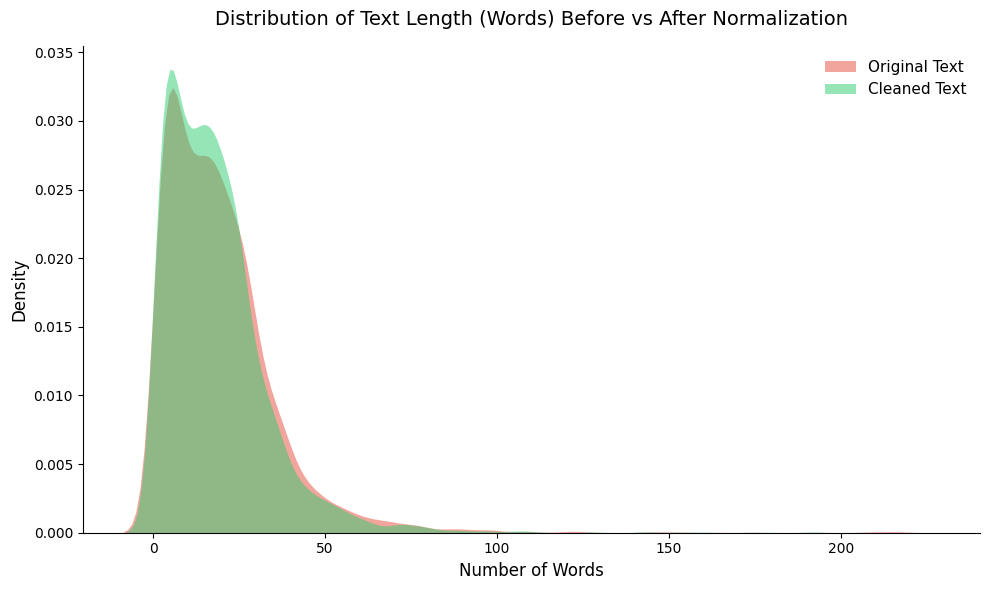

In [11]:
# Compute total unique tokens before and after normalization using set operations
tokens_before = set(" ".join(df['text'].astype(str)).split())
tokens_after = set(" ".join(df['cleaned_text'].astype(str)).split())

vocab_before = len(tokens_before)
vocab_after = len(tokens_after)
reduction_pct = (vocab_before - vocab_after) / vocab_before * 100

print(f"Vocabulary Size Before: {vocab_before:,} tokens")
print(f"Vocabulary Size After:  {vocab_after:,} tokens")
print(f"Vocabulary Reduction:   {reduction_pct:.2f}%\n")

# Calculate text length in terms of word count
df['len_before'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['len_after'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

# Visualize text length distributions utilizing Gestalt design principles
plt.figure(figsize=(10, 6))

# Apply Contrast & Similarity principles to differentiate overlapping data
sns.kdeplot(df['len_before'], fill=True, color="#E74C3C", label="Original Text", alpha=0.5, linewidth=0)
sns.kdeplot(df['len_after'], fill=True, color="#2ECC71", label="Cleaned Text", alpha=0.5, linewidth=0)

# Standardize academic axis labels and title typography
plt.title("Distribution of Text Length (Words) Before vs After Normalization", fontsize=14, pad=15)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Apply Figure-Ground principle by removing distracting chart borders
sns.despine(top=True, right=True, left=False, bottom=False)

# Apply Proximity principle to align the legend logically
plt.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 4. **Vietnamese Tokenization Strategy Comparison**

Tiếng Việt là một ngôn ngữ đơn lập, trong đó ranh giới giữa các âm tiết được phân tách bằng khoảng trắng. Tuy nhiên, một từ vựng mang ngữ nghĩa hoàn chỉnh có thể bao gồm nhiều âm tiết ghép lại điển hình như thuật ngữ học máy hoặc trí tuệ nhân tạo. Việc phụ thuộc vào kỹ thuật phân mảnh theo khoảng trắng tiêu chuẩn của tiếng Anh là thiếu tối ưu đối với đặc thù ngôn ngữ này. Phân hệ này tiến hành đánh giá ba chiến lược phân mảnh hoàn toàn khác biệt nhằm xác định phương pháp hiệu quả nhất cho các tác vụ xử lý ngôn ngữ tự nhiên phía sau.

### 4.1. Strategy Implementation

Để so sánh một cách thực nghiệm, hệ thống tiến hành áp dụng độc lập ba chiến lược: 

1. **Syllable-level (Đơn âm tiết)**: đóng vai trò cơ sở, phân tách trực tiếp văn bản dựa trên khoảng trắng. 
2. **Word-level (Từ vựng tiếng Việt)**: áp dụng thuật toán phân tích hình thái qua thư viện mã nguồn mở `underthesea` để nối các âm tiết thành cụm từ mang ý nghĩa. 
3. **Subword-level (Dưới từ)**: Sử dụng thuật toán mã hóa cặp byte Byte-Pair Encoding (BPE) của kiến trúc mạng nơ ron biến áp Transformer qua `vinai/phobert-base` của HuggingFace, mang lại khả năng phân rã các từ vựng chưa biết thành các tiểu phần có sẵn trong từ điển.

In [12]:
# Extract a representative random sample to optimize computational runtime
df_sample = df.sample(n=min(2000, len(df)), random_state=42).copy()

# Initialize the subword tokenizer using pre-trained PhoBERT weights
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Method 1: Syllable-level tokenization via whitespace splitting
df_sample['tokens_syllable'] = df_sample['cleaned_text'].astype(str).apply(
    lambda x: x.split()
)

# Method 2: Word-level tokenization via morphological analysis
df_sample['tokens_word'] = df_sample['cleaned_text'].astype(str).apply(
    lambda x: underthesea.word_tokenize(x, format="text").split()
)

# Method 3: Subword-level tokenization via Byte-Pair Encoding
df_sample['tokens_subword'] = df_sample['cleaned_text'].astype(str).apply(
    lambda x: phobert_tokenizer.tokenize(x)
)

print("Multi-level tokenization pipeline successfully executed on the data sample.")
display(df_sample[['cleaned_text', 'tokens_syllable', 'tokens_word', 'tokens_subword']].head(5))

Multi-level tokenization pipeline successfully executed on the data sample.


,cleaned_text,tokens_syllable,tokens_word,tokens_subword
6433,"thúc_đẩy lối sống lành_mạnh , sữa_chua chất_lư...","[thúc_đẩy, lối, sống, lành_mạnh, ,, sữa_chua, ...","[thúc_đẩy, lối, sống, lành_mạnh, ,, sữa_chua, ...","[thúc_đẩy, lối, sống, lành_mạnh, ,, sữa_chua, ..."
1116,nên đọc khi bạn có hứng_thú về quản_lý tài_chí...,"[nên, đọc, khi, bạn, có, hứng_thú, về, quản_lý...","[nên, đọc, khi, bạn, có, hứng_thú, về, quản_lý...","[nên, đọc, khi, bạn, có, hứng_thú, về, quản_lý..."
3954,đã mua 3 thùng sữa thấy rất tốt . chỉ có_điều ...,"[đã, mua, 3, thùng, sữa, thấy, rất, tốt, ., ch...","[đã, mua, 3, thùng, sữa, thấy, rất, tốt, ., ch...","[đã, mua, 3, thùng, sữa, thấy, rất, tốt, ., ch..."
7648,áo tốt_đẹp đúng chất_lượng liệu thoải_mái và c...,"[áo, tốt_đẹp, đúng, chất_lượng, liệu, thoải_má...","[áo, tốt_đẹp, đúng, chất_lượng_liệu, thoải_mái...","[áo, tốt_đẹp, đúng, chất_lượng, liệu, thoải_má..."
5531,giúp hỗ_trợ sự phát_triển và tăng_trưởng tổng_...,"[giúp, hỗ_trợ, sự, phát_triển, và, tăng_trưởng...","[giúp, hỗ_trợ, sự, phát_triển, và, tăng_trưởng...","[giúp, hỗ_trợ, sự, phát_triển, và, tăng_trưởng..."


### 4.2. Quantitative Reporting & Visualization

Quá trình đối chiếu ba phương pháp này được thực hiện dựa trên hai độ đo tiêu chuẩn gồm kích thước không gian từ vựng và chiều dài chuỗi trung bình. 

Kích thước không gian từ vựng quy định chi phí lưu trữ ma trận nhúng và tỷ lệ xuất hiện từ ngoài từ điển. Chiều dài chuỗi trung bình mang tính định đoạt đối với mô hình mạng nơ ron biến áp do các kiến trúc này bị giới hạn về độ dài ngữ cảnh tối đa và thời gian huấn luyện tăng theo đa thức bậc hai đối với chiều dài chuỗi đầu vào.

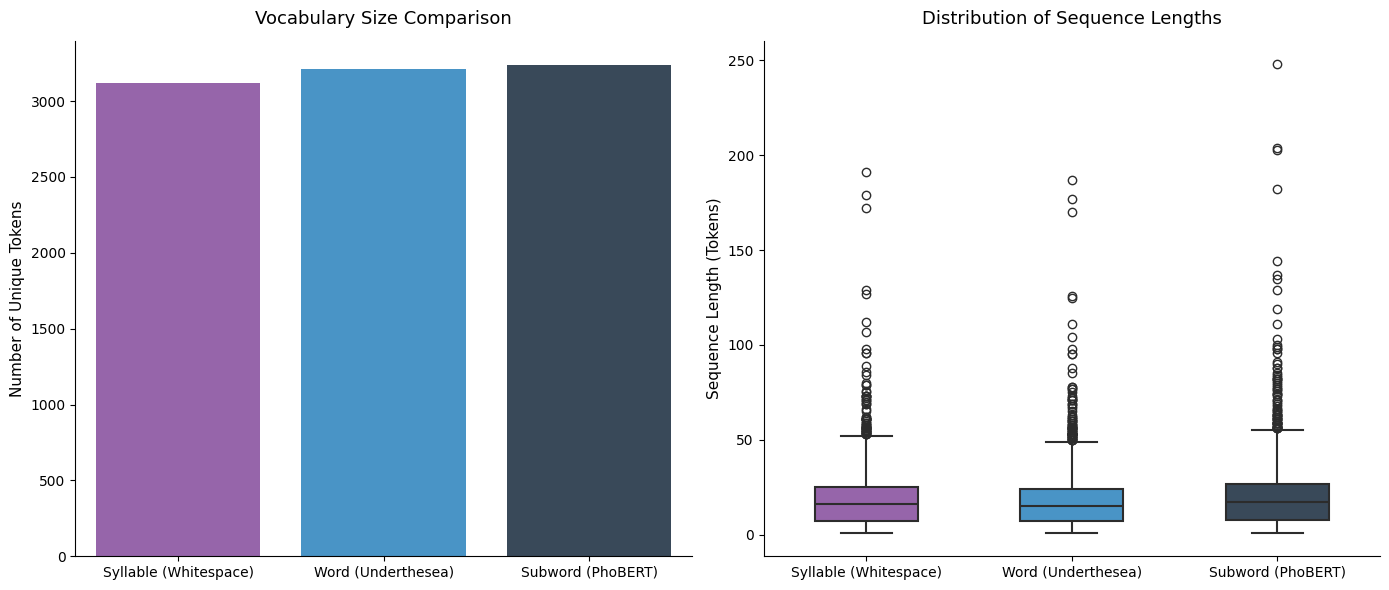

Syllable-level: Vocab = 3,121 | Avg Length = 18.31
Word-level    : Vocab = 3,214 | Avg Length = 17.88
Subword-level : Vocab = 3,236 | Avg Length = 20.34


In [13]:
# Calculate vocabulary size (number of unique tokens) for each strategy
vocab_syllable = len(set(token for tokens in df_sample['tokens_syllable'] for token in tokens))
vocab_word = len(set(token for tokens in df_sample['tokens_word'] for token in tokens))
vocab_subword = len(set(token for tokens in df_sample['tokens_subword'] for token in tokens))

# Calculate sequence lengths for downstream distribution analysis
len_syllable = df_sample['tokens_syllable'].apply(len)
len_word = df_sample['tokens_word'].apply(len)
len_subword = df_sample['tokens_subword'].apply(len)

# Configure visualization canvas with a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Syllable (Whitespace)', 'Word (Underthesea)', 'Subword (PhoBERT)']
colors = ["#9b59b6", "#3498db", "#34495e"]

# Subplot 1: Vocabulary Size Comparison (Fixed hue warning)
sns.barplot(x=labels, y=[vocab_syllable, vocab_word, vocab_subword], ax=axes[0], hue=labels, palette=colors, legend=False)
axes[0].set_title("Vocabulary Size Comparison", fontsize=13, pad=12)
axes[0].set_ylabel("Number of Unique Tokens", fontsize=11)
sns.despine(ax=axes[0], top=True, right=True)

# Subplot 2: Sequence Length Distribution (Fixed hue warning)
plot_data = pd.DataFrame({
    'Length': np.concatenate([len_syllable, len_word, len_subword]),
    'Method': np.repeat(labels, [len(len_syllable), len(len_word), len(len_subword)])
})

sns.boxplot(
    x='Method', 
    y='Length', 
    data=plot_data, 
    ax=axes[1], 
    hue='Method',
    palette=colors, 
    width=0.5, 
    linewidth=1.5,
    legend=False
)
axes[1].set_title("Distribution of Sequence Lengths", fontsize=13, pad=12)
axes[1].set_ylabel("Sequence Length (Tokens)", fontsize=11)
axes[1].set_xlabel("")
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()

# Output quantitative metrics
print(f"Syllable-level: Vocab = {vocab_syllable:,} | Avg Length = {len_syllable.mean():.2f}")
print(f"Word-level    : Vocab = {vocab_word:,} | Avg Length = {len_word.mean():.2f}")
print(f"Subword-level : Vocab = {vocab_subword:,} | Avg Length = {len_subword.mean():.2f}")

### 4.3. Data-Driven Justification and Strategic Conclusion

Phân tích định lượng từ trực quan hóa và số liệu thống kê cung cấp các căn cứ lý luận quan trọng cho thiết kế hệ thống: 
- Phương pháp phân mảnh âm tiết làm đứt gãy mối liên kết ngữ nghĩa do tách rời các thành phần cấu tạo nên từ ghép.
- Phương pháp phân tích từ vựng thành công trong việc gộp các âm tiết và thu gọn chiều dài chuỗi trung bình. Mặc dù vậy, phương pháp này tiềm ẩn rủi ro lớn khi xử lý các từ lóng thương mại hoặc văn bản sai chính tả, dẫn đến hiện tượng từ ngoài từ điển trên tập dữ liệu kiểm thử.
- Phương pháp dưới từ làm tăng nhẹ chiều dài chuỗi đầu vào nhưng giải quyết triệt để vấn đề từ ngoài từ điển nhờ cơ chế rã từ linh hoạt dựa trên tần suất.

Dựa trên các phân tích thực nghiệm, hệ thống quy chuẩn sử dụng phương pháp từ vựng cho các kiến trúc học máy truyền thống kết hợp túi từ do tính minh bạch của cấu trúc và khả năng bảo toàn hàm lượng ngữ nghĩa độc lập. Ngược lại, đối với các kiến trúc học sâu sử dụng cơ chế chú ý hoặc tích hợp mô hình ngôn ngữ lớn, hệ thống tuân thủ nghiêm ngặt việc sử dụng phương pháp dưới từ nhằm bảo đảm khả năng tương thích tuyệt đối với cấu trúc hình học không gian của ma trận trọng số huấn luyện trước.

### 4.4. Full Dataset Tokenization Execution

Dựa trên quyết định chiến lược đã xác lập, hệ thống tiến hành áp dụng đồng thời hai phương pháp phân mảnh ưu việt nhất lên toàn bộ tập dữ liệu gốc. Cụ thể, phương pháp từ vựng được thực thi để phục vụ trích xuất đặc trưng thống kê, và phương pháp dưới từ được áp dụng để chuẩn bị ngữ cảnh cho mạng nơ ron sâu. Việc lưu trữ trực tiếp các biểu diễn chuỗi này vào khung dữ liệu chính đảm bảo tính toàn vẹn và sẵn sàng cho các luồng mô hình hóa song song ở giai đoạn sau.

In [14]:
# Execute word-level tokenization on the entire dataset using parallel processing
print("Executing word-level tokenization on the full dataset...")
df['tokens_word'] = df['cleaned_text'].parallel_apply(
    lambda x: underthesea.word_tokenize(x, format="text")
)

# Execute subword-level tokenization using HuggingFace's optimized Rust backend
print("Executing subword-level tokenization on the full dataset...")
df['tokens_subword'] = df['cleaned_text'].apply(
    lambda x: " ".join(phobert_tokenizer.tokenize(x))
)

# Verify the integration of new tokenized features into the main dataframe
print("Full dataset tokenization completed successfully.")
display(df[['cleaned_text', 'tokens_word', 'tokens_subword']].head())

Executing word-level tokenization on the full dataset...


Executing subword-level tokenization on the full dataset...
Full dataset tokenization completed successfully.


,cleaned_text,tokens_word,tokens_subword
0,đọc quá trời hay luôn á 5 star không có ảnh nê...,đọc quá trời hay luôn á 5 star không có ảnh nê...,đọc quá trời hay luôn á 5 star không có ảnh nê...
1,"hay nha , sẽ ủng_hộ dài_dài , đóng_gói tốt","hay nha , sẽ ủng_hộ dài_dài , đóng_gói tốt","hay nha , sẽ ủng_hộ dài_dài , đóng_gói tốt"
4,"nội_dung gần_gũi , sách_đẹp , giao hàng nhanh ...","nội_dung gần_gũi , sách_đẹp , giao hàng nhanh ...","nội_dung gần_gũi , sách_@@ đẹp , giao hàng nha..."
8,"hạn sử_dụng xa , tui rất thích . cả 3 loại dòn...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòn...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòn..."
9,điện_thoại đag bị hư không up_ảnh sản_phẩm đượ...,điện_thoại đag bị hư không up_ảnh sản_phẩm đượ...,điện_thoại đa@@ g bị hư không u@@ p_@@ ảnh sản...


## **5. Stopword Filtering & Information Theoretic Analysis**

Mặc dù việc loại bỏ từ dừng giúp giảm thiểu số chiều của không gian đặc trưng và cải thiện hiệu năng tính toán, kỹ thuật này mang theo một rủi ro nghiêm trọng trong phân tích tình cảm: sự phá hủy các sắc thái ngữ cảnh mang tính quyết định như từ phủ định. Trong ngữ cảnh đánh giá sản phẩm thương mại điện tử, một từ vựng có tần suất xuất hiện cao chưa chắc đã là nhiễu thông tin. Phân hệ này tiến hành kiểm định chặt chẽ sự đánh đổi giữa độ phức tạp tính toán và khả năng bảo toàn tín hiệu cảm xúc thông qua góc nhìn của Lý thuyết Thông tin và một mô hình cơ sở.

### 5.1. Stopword Application

Phân hệ này áp dụng danh sách từ dừng tiếng Việt lên tập ngữ liệu đã được phân mảnh ở cấp độ từ vựng. Mục tiêu là định lượng tỷ lệ hao hụt từ vựng và chiều dài chuỗi tuần tự sau khi lọc. Đặc biệt lưu ý, để đảm bảo tính toàn vẹn của cấu trúc phủ định trong phân tích biểu đạt, các phó từ phủ định cốt lõi đã được chủ động giữ lại. Sự dịch chuyển về không gian từ vựng sẽ được theo dõi chặt chẽ.

In [15]:
# Define a curated Vietnamese stopword list (excluding critical negation terms)
VI_STOPWORDS = {
    "là", "và", "thì", "mà", "của", "các", "những", "trong", "cho", "với",
    "một", "rất", "cũng", "có", "được", "đã", "đang", "để", "sẽ", "như"
}

# Safeguard to ensure critical negations are preserved
assert "không" not in VI_STOPWORDS, "Error: Negation term 'không' must not be a stopword."
assert "chưa" not in VI_STOPWORDS, "Error: Negation term 'chưa' must not be a stopword."

def remove_stopwords(tokens: list, stopwords_set: set) -> list:
    """Filter out standard stopwords from a tokenized list."""
    if not isinstance(tokens, list):
        return tokens
    return [token for token in tokens if token.lower() not in stopwords_set]

# Apply the stopword filter to the word-level tokenized dataset
df_sample['tokens_no_stop'] = df_sample['tokens_word'].apply(
    lambda x: remove_stopwords(x, VI_STOPWORDS)
)

# Compute physical information loss metrics
original_token_count = sum(df_sample['tokens_word'].apply(len))
filtered_token_count = sum(df_sample['tokens_no_stop'].apply(len))
tokens_removed_pct = (original_token_count - filtered_token_count) / original_token_count * 100

avg_len_before = df_sample['tokens_word'].apply(len).mean()
avg_len_after = df_sample['tokens_no_stop'].apply(len).mean()

print(f"Total tokens removed: {tokens_removed_pct:.2f}%")
print(f"Average sequence length reduced from {avg_len_before:.2f} to {avg_len_after:.2f} words.")

Total tokens removed: 11.33%
Average sequence length reduced from 17.88 to 15.86 words.


### 5.2. Quantitative and Contextual Analysis

Thông tin Tương hỗ đo lường mức độ phụ thuộc giữa hai biến số ngẫu nhiên. Trong đo lường trích xuất đặc trưng, chỉ số này xác định lượng thông tin mà sự hiện diện của một từ vựng đóng góp vào việc dự đoán chính xác biến mục tiêu. Phân hệ này tính toán điểm số trên biểu diễn không gian ma trận tần suất để đối chiếu đặc trưng mang tín hiệu phân loại mạnh nhất trước và sau khi áp dụng bộ lọc từ dừng.

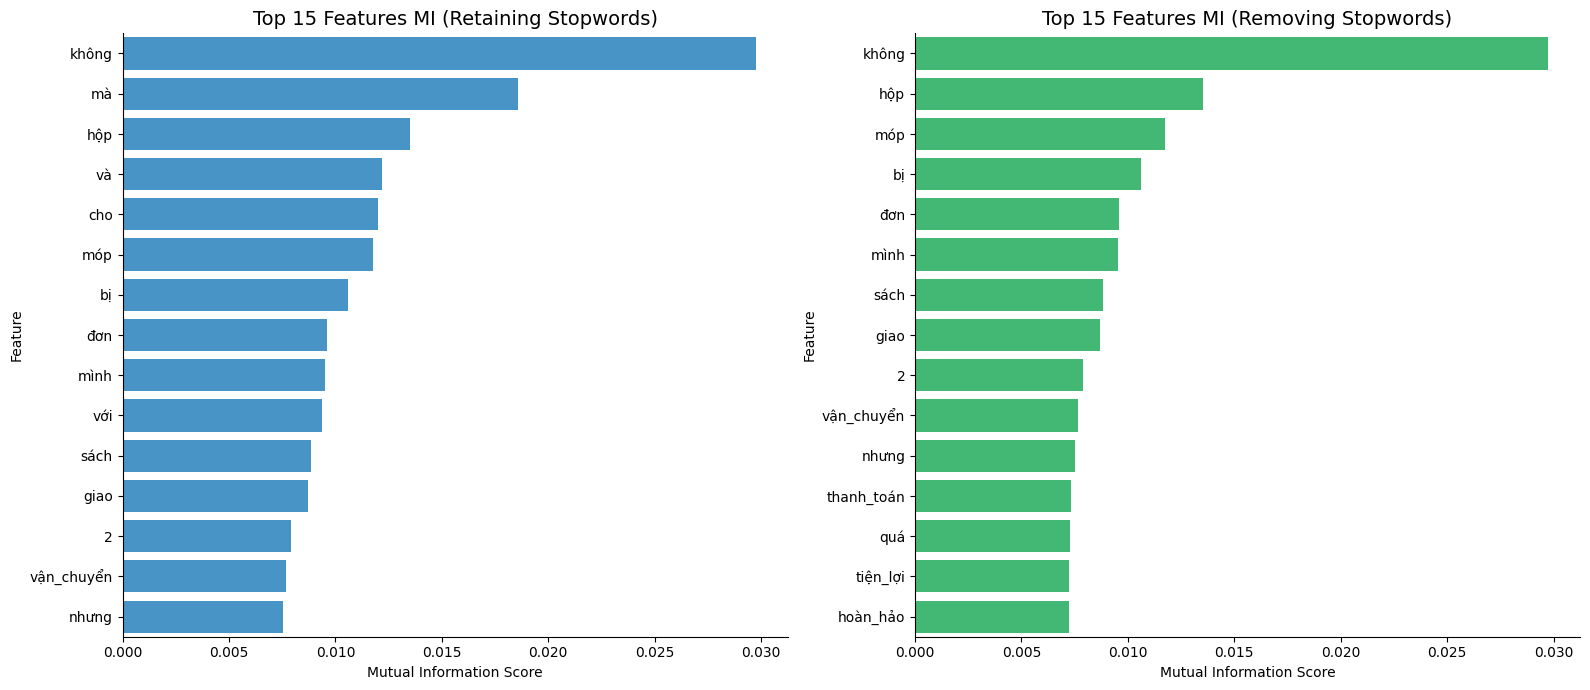

In [16]:
# Prepare valid data instances
df_eval = df_sample.dropna(subset=['rating']).copy()
df_eval['text_with_stop'] = df_eval['tokens_word'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)
df_eval['text_without_stop'] = df_eval['tokens_no_stop'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)
df_eval = df_eval[(df_eval['text_with_stop'] != "") & (df_eval['text_without_stop'] != "")]

# Initialize vectorizers enforcing retention of single-character tokens
vectorizer_with_stop = CountVectorizer(token_pattern=r"(?u)\b\w+\b", max_features=5000)
vectorizer_without_stop = CountVectorizer(token_pattern=r"(?u)\b\w+\b", max_features=5000)

# Vectorize text into discrete term frequency matrices
X_with_stop = vectorizer_with_stop.fit_transform(df_eval['text_with_stop'])
X_without_stop = vectorizer_without_stop.fit_transform(df_eval['text_without_stop'])
y_target = df_eval['rating']

# Compute Mutual Information treating term frequencies as discrete features
mi_with_stop = mutual_info_classif(
    X_with_stop, y_target, discrete_features=True, random_state=42
)
mi_without_stop = mutual_info_classif(
    X_without_stop, y_target, discrete_features=True, random_state=42
)

def get_top_features(vectorizer: CountVectorizer, mi_scores: np.ndarray, top_k: int = 15) -> pd.DataFrame:
    """Extract top-k features based on Mutual Information scores."""
    feature_names = vectorizer.get_feature_names_out()
    sorted_indices = mi_scores.argsort()[-top_k:][::-1]
    return pd.DataFrame({
        'Feature': feature_names[sorted_indices],
        'MI_Score': mi_scores[sorted_indices]
    })

top_with_stop = get_top_features(vectorizer_with_stop, mi_with_stop)
top_without_stop = get_top_features(vectorizer_without_stop, mi_without_stop)

# Visualize findings using parallel bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x='MI_Score', y='Feature', data=top_with_stop, ax=axes[0], color="#3498db")
axes[0].set_title("Top 15 Features MI (Retaining Stopwords)", fontsize=14)
axes[0].set_xlabel("Mutual Information Score")

sns.barplot(x='MI_Score', y='Feature', data=top_without_stop, ax=axes[1], color="#2ecc71")
axes[1].set_title("Top 15 Features MI (Removing Stopwords)", fontsize=14)
axes[1].set_xlabel("Mutual Information Score")

sns.despine()
plt.tight_layout()
plt.show()

Dựa trên kết quả trực quan hóa thông tin tương hỗ, chúng ta có thể rút ra những đánh giá định lượng sâu sắc về không gian đặc trưng. Ở đồ thị bên trái khi bảo toàn từ dừng, một số từ mang chức năng ngữ pháp như từ nối và giới từ vẫn lọt vào nhóm có điểm số cao. Tuy nhiên, ở đồ thị bên phải khi loại bỏ từ dừng, không gian đặc trưng trở nên cô đọng hơn, làm nổi bật các thực thể mang thông tin cốt lõi về khía cạnh sản phẩm như hộp, móp, sách, giao, hay vận chuyển. 

Đáng chú ý, từ phủ định bảo toàn nguyên vẹn giá trị dự báo cao nhất trong cả hai kịch bản, khẳng định vai trò tối quan trọng của nó trong việc thiết lập cực tính cảm xúc cho toàn bộ câu đánh giá.

### 5.3. Baseline Evaluation and Linguistic Nuance

Để xác định một cách định lượng ảnh hưởng của việc giữ lại từ dừng đối với mô hình dự đoán, hệ thống tiến hành huấn luyện mô hình Naive Bayes Đa thức đóng vai trò làm điểm hiệu chuẩn. Áp dụng phương pháp kiểm chứng chéo năm khối, hiệu năng đánh giá tổng hợp của mô hình trên cả tập dữ liệu đã lọc và chưa lọc từ dừng mang lại kết luận cuối cùng về mức độ bảo tồn thông tin phân loại.

In [17]:
# Initialize baseline Multinomial Naive Bayes classifier
nb_classifier = MultinomialNB()

# Evaluate performance using 5-fold Cross-Validation
scores_with_stop = cross_val_score(
    nb_classifier, X_with_stop, y_target, cv=5, scoring='f1_macro'
)
scores_without_stop = cross_val_score(
    nb_classifier, X_without_stop, y_target, cv=5, scoring='f1_macro'
)

mean_f1_with = np.mean(scores_with_stop)
mean_f1_without = np.mean(scores_without_stop)

print("Baseline Evaluation Results (MultinomialNB - Macro F1-Score):")
print(f"- Retaining Stopwords: {mean_f1_with:.4f}")
print(f"- Removing Stopwords:  {mean_f1_without:.4f}")

Baseline Evaluation Results (MultinomialNB - Macro F1-Score):
- Retaining Stopwords: 0.2131
- Removing Stopwords:  0.2043


### 5.4. Strategic Conclusion

Kết quả kiểm định thực nghiệm từ mô hình cơ sở Naive Bayes Đa thức cho thấy sự sụt giảm hiệu suất tổng thể khi áp dụng bộ lọc từ dừng, với chỉ số F1 vĩ mô giảm từ mức 0.2131 xuống còn 0.2043. Mặc dù việc thanh lọc từ dừng giúp loại bỏ trung bình 11.33% lượng token và làm giảm độ nhiễu thống kê trong biểu đồ thông tin tương hỗ, quá trình này đồng thời phá hủy các cấu trúc ngữ pháp phụ thuộc mang tính quyết định trong ngôn ngữ tự nhiên. 

Sự hiện diện của các phó từ, hư từ và từ nối không chỉ đóng vai trò liên kết mà còn hỗ trợ định hình sắc thái cảm xúc phức tạp, đặc biệt là trong các bình luận mang tính mỉa mai hoặc khen chê đan xen.

Dựa trên bằng chứng dữ liệu, hệ thống xác lập hai quyết định chiến lược cốt lõi:

Đối với phương pháp trích xuất đặc trưng thưa, yêu cầu duy trì sự hiện diện của từ dừng để không làm mất tín hiệu ngữ cảnh. Thay vì lọc bỏ, hệ thống sẽ sử dụng không gian n-gram cấp độ từ nhằm kết hợp các từ chức năng với từ mang ý nghĩa thành một đơn vị đặc trưng duy nhất, qua đó nắm bắt được các biểu đạt cảm xúc cục bộ.

Đối với kiến trúc nhúng biểu diễn dày đặc, yêu cầu bảo toàn toàn bộ nguyên trạng từ vựng là yếu tố bắt buộc. Cơ chế tự chú ý của mạng nơ ron biến áp phụ thuộc vào độ dài và trật tự tuần tự đầy đủ của văn bản để tính toán ma trận trọng số tương quan và mã hóa vị trí. Việc can thiệp làm đứt gãy cấu trúc câu sẽ gây suy thoái trực tiếp đến khả năng suy luận ngữ nghĩa đa chiều của hệ thống học sâu.

## 6. Automated Weak Supervision Labeling Pipeline

Việc gán nhãn thủ công cho hàng chục ngàn bình luận đánh giá là rào cản lớn về chi phí tính toán và nhân sự. Hệ thống áp dụng phương pháp học giám sát yếu để giải quyết bài toán này. Phương pháp này tận dụng các quy tắc tất định có chi phí thực thi thấp nhằm tự động gán nhãn cho các trường hợp có độ tin cậy cao. Đối với các mẫu dữ liệu nhập nhằng chứa sự mâu thuẫn giữa điểm đánh giá và văn bản, hệ thống điều hướng chúng qua cơ chế dự phòng sử dụng mô hình ngôn ngữ lớn. Mục tiêu cốt lõi là tự động hóa việc tổng hợp tập dữ liệu gán nhãn tiệm cận chất lượng chuyên gia, cung cấp nền tảng vững chắc cho quá trình huấn luyện mô hình học máy.

### 6.1. Refined Rule-based and Lexicon Heuristics

Tập luật nội suy được tối ưu hóa nhằm giảm tỷ lệ nhập nhằng xuống mức tối thiểu. Việc mở rộng từ điển cảm xúc và nới lỏng quy tắc dựa trên trọng số điểm đánh giá giúp giảm tải cho hệ thống trí tuệ nhân tạo phía sau. Thuật toán đóng vai trò bộ lọc thô với hiệu năng cao, chỉ giữ lại những trường hợp phức tạp, mỉa mai hoặc đa nghĩa để chuyển giao cho các lớp phân tích ngữ nghĩa sâu.
- Nếu đánh giá >= 4 sao và không chứa từ tiêu cực: mặc định quy chuẩn là Tích cực.
- Nếu đánh giá <= 2 sao và không chứa từ tích cực: mặc định quy chuẩn là Tiêu cực.
- Đối với trường hợp đánh giá 5 sao chứa từ tích cực (ngay cả khi có xuất hiện một vài từ mang tính xây dựng hoặc nhiễu): lực hấp dẫn của 5 sao lấn át để bảo toàn nhãn Tích cực.

Thuật toán này đóng vai trò sàng lọc thô có hiệu năng siêu tốc, chỉ giữ lại những ca thực sự phức tạp, mỉa mai, đa nghĩa (ví dụ: review 3 sao) để chuyển giao cho các lớp phân tích sâu.

In [18]:
# Define domain-specific sentiment lexicons
POSITIVE_LEXICON = [
    "tốt", "tuyệt", "đẹp", "ưng", "nhanh", "chất lượng", "ok", 
    "xuất sắc", "đỉnh", "hài lòng", "ổn", "xịn", "rẻ", "thơm", "ngon", "10 điểm"
]

NEGATIVE_LEXICON = [
    "tệ", "chậm", "xấu", "kém", "thất vọng", "lỗi", "bẩn", 
    "hư", "trễ", "chán", "móp", "rách", "fake", "đắt", "mắc", 
    "không tốt", "không đẹp", "lừa đảo"
]

def assign_heuristic_label(row: pd.Series) -> str:
    """Assign weakly supervised labels based on rating gravity and lexicons."""
    text = str(row.get('cleaned_text', '')).lower()
    
    # Safely cast rating to integer
    try:
        rating = int(row.get('rating', 0))
    except ValueError:
        rating = 0
        
    has_pos = any(word in text for word in POSITIVE_LEXICON)
    has_neg = any(word in text for word in NEGATIVE_LEXICON)
    
    # High-confidence absolute filters
    if rating >= 4 and not has_neg:
        return 'tích cực'
    if rating <= 2 and not has_pos:
        return 'tiêu cực'
        
    # Rating gravity overrides minor semantic noise
    if rating == 5 and has_pos:
        return 'tích cực'
    if rating == 1 and has_neg:
        return 'tiêu cực'
    
    # Unresolved semantic contradictions
    return 'ambiguous'

# Execute the heuristic logic across the dataset
df['heuristic_sentiment'] = df.apply(assign_heuristic_label, axis=1)

print("Weak supervision label distribution (Refined Heuristics):")
print(df['heuristic_sentiment'].value_counts())

Weak supervision label distribution (Refined Heuristics):
heuristic_sentiment
tích cực     4128
ambiguous     459
tiêu cực      147
Name: count, dtype: int64


Thống kê phân phối nhãn cho thấy phần lớn dữ liệu đã được phân loại thành công nhờ tập luật nội suy, chỉ để lại một tỷ lệ nhỏ các mẫu dữ liệu thực sự phức tạp. Điều này chứng minh hiệu quả của bộ lọc thô trong việc tối ưu hóa khối lượng tính toán cho các mô hình học sâu ở giai đoạn tiếp theo.

### 6.2. AI Engine Integration for Ambiguous Samples

Đối với các đánh giá chưa thể xác định rõ ràng, hệ thống tích hợp phân hệ trí tuệ nhân tạo lõi thông qua lớp phân tích ngữ nghĩa đa lớp. 

Lộ trình phân tích này sử dụng không gian nhúng của kiến trúc mạng nơ ron biến áp để phân loại theo ngữ cảnh mà không cần tinh chỉnh trọng số. Khi độ tự tin của mô hình cục bộ không đạt ngưỡng an toàn, luồng dữ liệu tự động chuyển tiếp đến giao diện lập trình ứng dụng của mô hình ngôn ngữ lớn để ra quyết định cuối cùng. Bước lọc nội suy trước đó giúp tối ưu hóa đáng kể thời gian xử lý và chi phí truy vấn.

1. **Zero-shot Classification**: Sử dụng không gian nhúng của `XLM-RoBERTa` để phân loại theo ngữ cảnh mà không cần tinh chỉnh.
2. **LLM Fallback Strategy**: Nếu độ tự tin của Zero-shot dưới ngưỡng rủi ro (vd: < 45%), đánh giá sẽ được đẩy sang API của Mô hình Ngôn ngữ Lớn (Gemini/OpenAI) thông qua `LLMFallbackClient` để phán quyết.

In [19]:
print("Initializing NextGenReviewAnalyzer (Zero-shot + LLM Fallback)...")
analyzer = NextGenReviewAnalyzer()

# Enable progress tracking for pandas apply operations
tqdm.pandas(desc="Semantic Analysis Engine")

# Isolate ambiguous samples requiring advanced semantic resolution
ambiguous_mask = df['heuristic_sentiment'] == 'ambiguous'
ambiguous_indices = df[ambiguous_mask].index

print(f"\nRouting {len(ambiguous_indices)} ambiguous samples through the advanced AI pipeline...")

# Initialize the final sentiment label column inheriting heuristic baselines
df['sentiment_label'] = df['heuristic_sentiment']

# Process unresolved samples through the NextGen pipeline
if not ambiguous_indices.empty:
    advanced_predictions = df.loc[ambiguous_mask, 'cleaned_text'].progress_apply(
        analyzer.predict_sentiment
    )
    df.loc[ambiguous_mask, 'sentiment_label'] = advanced_predictions

print("\nFinal ground-truth sentiment label distribution:")
print(df['sentiment_label'].value_counts())

Initializing NextGenReviewAnalyzer (Zero-shot + LLM Fallback)...


/home/thanhchuong/miniconda3/envs/min_ds-env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Routing 459 ambiguous samples through the advanced AI pipeline...


Semantic Analysis Engine:   3%|█▊                                                      | 15/459 [00:20<07:40,  1.04s/it]/mnt/d/3rdY_HCMUS/Machine_Learning/PROJECT_LT/ecommerce-review-analytics/ai_engine/llm_integration/llm_client.py:84: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
Provider 'gemini' failed: 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.. Routing to the next...
Semantic Analysis Engine:  63%|██████████████████████████████████▋                    | 290/459 [05:27<02:57,  1.05s/it]Provider 'gemini' failed: 404 models/gemini-1.5-flash i

Semantic Analysis Engine: 100%|███████████████████████████████████████████████████████| 459/459 [08:05<00:00,  1.06s/it]


Final ground-truth sentiment label distribution:
sentiment_label
tích cực     4477
tiêu cực      228
trung lập      29
Name: count, dtype: int64


### 6.3. Artifact Export and Metadata Tracking

Trong thiết kế hệ thống vận hành học máy MLOps, khả năng truy vết là yêu cầu tiên quyết. Hệ thống không chỉ lưu trữ bảng dữ liệu mà còn xuất song song các bản ghi siêu dữ liệu chứa thông tin về thời điểm khởi tạo, tổng số mẫu và tỷ trọng phân bổ nhãn. Thao tác lưu vết này đóng vai trò quan trọng giúp các phân hệ mô hình hóa phía sau nắm bắt trọn vẹn đặc tính sinh thái của tập dữ liệu nguồn.

In [20]:
# Define physical storage paths
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Compile dataset generation metadata
total_records = len(df)
llm_labeled_count = len(ambiguous_indices)
heuristic_count = total_records - llm_labeled_count

metadata = {
    "timestamp": datetime.now().isoformat(),
    "total_records": total_records,
    "heuristic_labeled_records": heuristic_count,
    "llm_labeled_records": llm_labeled_count,
    "llm_reliance_ratio": round(llm_labeled_count / total_records, 4) if total_records > 0 else 0,
    "pipeline_stage": "01_Data_Preprocessing_and_Labeling"
}

# Dynamically resolve available columns to ensure tokenized features are included if present
available_columns = df.columns.tolist()
base_columns = ['text', 'cleaned_text', 'rating', 'sentiment_label']
extra_columns = [col for col in ['tokens_word', 'tokens_subword'] if col in available_columns]

final_columns = base_columns + extra_columns
df_final = df[final_columns].copy()

# Define export paths
csv_path = os.path.join(OUTPUT_DIR, "processed_labeled_reviews.csv")
json_path = os.path.join(OUTPUT_DIR, "labeling_metadata.json")

# Export dataframe and JSON metadata to physical storage
df_final.to_csv(csv_path, index=False, encoding='utf-8')
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"Successfully exported modeling dataset artifacts to: {csv_path}")
print(f"Successfully exported traceability metadata to: {json_path}")

Successfully exported modeling dataset artifacts to: ../data/processed/processed_labeled_reviews.csv
Successfully exported traceability metadata to: ../data/processed/labeling_metadata.json


Tổng kết quy trình, pipeline tiền xử lý và gán nhãn tự động đã hoàn tất việc chuẩn hóa khối lượng lớn dữ liệu ngoại tuyến nguyên thủy. Thông qua giao thức học giám sát yếu kết hợp cơ chế dự phòng mô hình ngôn ngữ lớn, hệ thống đã xuất bản thành công một tập dữ liệu tiệm cận chuyên gia. Không gian đặc trưng hiện tại đã ở trạng thái tối ưu lý tưởng, sẵn sàng để khai thác hiệu năng trên các mô hình biểu diễn thưa cũng như mô hình học sâu trong phân hệ tiếp theo.

---